In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

In [2]:
folder_path = r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\financial_dataset"
dfs = []
for file in glob.glob(folder_path + r"\*.csv"):
    df_temp = pd.read_csv(file, encoding="latin-1", header=None, names=["sentiment", "headline"])
    dfs.append(df_temp)

In [3]:
df = pd.concat(dfs, ignore_index=True)
df.dropna(subset=["sentiment", "headline"], inplace=True)
df.drop_duplicates(subset=["headline"], inplace=True)
df["sentiment"] = df["sentiment"].str.strip().str.lower()

In [4]:
valid_labels = ["positive", "negative", "neutral"]
df = df[df["sentiment"].isin(valid_labels)]

# Verify
print("Shape after cleaning:", df.shape)
print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())
print("\nFirst 5 rows:")
print(df.head())

Shape after cleaning: (4837, 2)

Sentiment Distribution:
sentiment
neutral     2871
positive    1362
negative     604
Name: count, dtype: int64

First 5 rows:
      sentiment                                           headline
14825   neutral  Technopolis plans to develop in stages an area...
14826  negative  The international electronic industry company ...
14827  positive  With the new production plant the company woul...
14828  positive  According to the company 's updated strategy f...
14829  positive  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


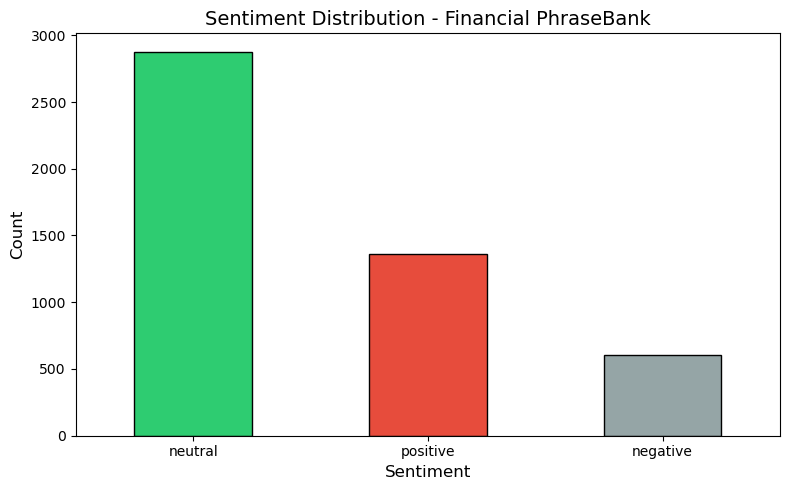

In [5]:
colors = ["#2ecc71", "#e74c3c", "#95a5a6"]
df["sentiment"].value_counts().plot(
    kind="bar",
    color=colors,
    edgecolor="black",
    figsize=(8, 5)
)
plt.title("Sentiment Distribution - Financial PhraseBank", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\sentiment_distribution.png", dpi=150)
plt.show()

In [6]:
df.to_csv(r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\financial_dataset_clean.csv", index=False)
print("Clean dataset saved.")

Clean dataset saved.


In [7]:
!pip install yfinance

In [8]:
import yfinance as yf
import pandas as pd

In [9]:
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

stock.columns = [col[0] if isinstance(col, tuple) else col for col in stock.columns]

stock["Price_Up"] = (stock["Close"].shift(-1) > stock["Close"]).astype(int)

stock.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [10]:
print("Shape:", stock.shape)
print("\nFirst 5 rows:")
print(stock.head())

Shape: (1006, 6)

First 5 rows:
                Close       High        Low       Open     Volume  Price_Up
Date                                                                       
2020-01-02  72.333878  72.394086  71.091184  71.344054  135480400         0
2020-01-03  71.630630  72.389250  71.406659  71.563198  146322800         1
2020-01-06  72.201416  72.239950  70.503554  70.754021  118387200         0
2020-01-07  71.861862  72.466345  71.642704  72.211064  108872000         1
2020-01-08  73.017830  73.318870  71.565614  71.565614  132079200         1


In [79]:
stock.to_csv(r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\aapl_stock_prices.csv")
print("\n Stock data saved.")


 Stock data saved.
